In [ ]:
# Configure API Settings

API_KEY = '8c11f83aedaf7cff87d541148c2691aa'
#A free key allows 60 calls per minute

BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'
#This is the API endpoint url

CITIES = ['Mumbai','Delhi','Bangalore','Chennai','Hyderabad','Kolkata','Pune','Jaipur']

print(f'API configured for {len(CITIES)} cities')
print(f'Cities: {CITIES}')
print('\nIMPORTANT: Replace your api key before running')

API configured for 8 cities
Cities: ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur']

IMPORTANT: Replace your api key before running


In [ ]:
import requests

# EXTRACT: Call API for each city

def fetch_weather(city,api_key):
    """
    Fetch current weather data fora given city.
    Returns a dictionary containing metrics or None on failure

    """
    params = {
        'q': city,              #city name query parameter
        'appid': api_key,       #
        'units': 'metric'
    }
    try:
      response = requests.get(BASE_URL,params=params,timeout=10)
      #requests.get() sends an HTTP GET request to BASE_URL
      #timeout=10- wait for 10 seconds: raise an error if no response
      if response.status_code == 200:
        #status_code 200 = HTTP OK = request was successful
        data = response.json()
        #.json() parses the json text body into a python dictionary

        return{
            'city': city,
            'temperature': round(data['main']['temp'],1),
            'feels_like': round(data['main']['feels_like'],1),
            'humidity': data['main']['humidity'],
            'pressure': data['main']['pressure'],
            'wind_speed' : round(data['wind']['speed'],1),
            'condition' : data['weather'][0]['description'].title(),
            'visibility' : data.get('visibility',0),

        }
      else:
          print(f'ERROR {response.status_code} for {city}: {response.text}') # Fixed f-string and added response.text
          return None
    except requests.exceptions.Timeout as e: # Added 'as e'
      print(f'ERROR: Timeout for {city} - {e}') # Improved error message
      return None
    except requests.exceptions.RequestConnectionError as e: # Catch other request-related errors
      print(f'ERROR: Request failed for {city} - {e}')
      return None


#Call API for all cities
print('Calling weather API...')
weather_record=[]

for city in CITIES:
          print(f' Fetching: {city}...',end='')
          record = fetch_weather(city,API_KEY)
          if record:
            weather_record.append(record)
            print(f' {record["temperature"]} C, {record["condition"]}') # Fixed tuple in print
          else:
            print('FAILED')
print(f'\nSuccessfully fetched weather data for {len(weather_record)} cities')
# The return weather_record here is likely meant for a function that calls this block, but given the current structure, it will just return at the end of the script execution if it's the last line executed in a cell.
# For now, I will keep it as is, assuming the user might wrap this in a function later if needed.
# If this block is intended to be executed directly in the global scope, the `return` statement will just exit the cell execution.
# For clarity, I'll remove the `return weather_record` if it's not within a function, as it won't behave as expected at the top level.
# Removed the `return weather_record` as it's not within a function scope.



Calling weather API...
 Fetching: Mumbai... 34.0 C, Haze
 Fetching: Delhi... 44.0 C, Clear Sky
 Fetching: Bangalore... 29.8 C, Scattered Clouds
 Fetching: Chennai... 36.2 C, Few Clouds
 Fetching: Hyderabad... 30.2 C, Broken Clouds
 Fetching: Kolkata... 32.0 C, Haze
 Fetching: Pune... 36.9 C, Overcast Clouds
 Fetching: Jaipur... 41.6 C, Haze

Successfully fetched weather data for 8 cities


In [ ]:
import pandas as pd

weather_df = pd.DataFrame(weather_record)
print(weather_df.to_string(index=False))
print(f'\nShape: {weather_df.shape}')
print(f'Missing values: {weather_df.isnull().sum().sum()}')
print(f'\nData types: ')
print(weather_df.dtypes)

     city  temperature  feels_like  humidity  pressure  wind_speed        condition  visibility
   Mumbai         34.0        41.0        59      1009         6.2             Haze        7000
    Delhi         44.0        41.1        10       999         5.1        Clear Sky        7000
Bangalore         29.8        31.5        55      1009         4.6 Scattered Clouds        8000
  Chennai         36.2        43.2        53      1005         4.1       Few Clouds        6000
Hyderabad         30.2        32.1        54      1008         7.7    Broken Clouds        6000
  Kolkata         32.0        37.6        62      1001         5.1             Haze        5000
     Pune         36.9        36.8        27      1008         3.8  Overcast Clouds       10000
   Jaipur         41.6        41.8        20      1001         4.6             Haze        4500

Shape: (8, 8)
Missing values: 0

Data types: 
city            object
temperature    float64
feels_like     float64
humidity         int

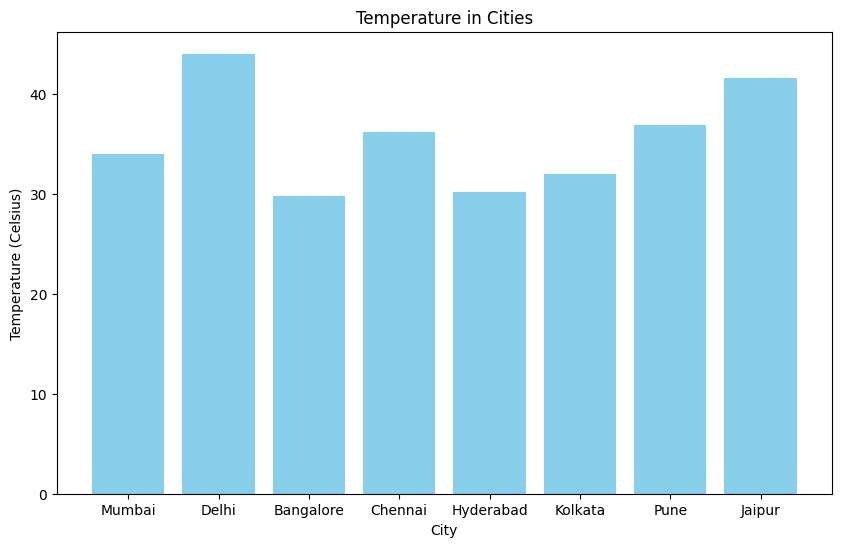

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import requests

plt.figure(figsize=(10, 6))
plt.bar(weather_df['city'], weather_df['temperature'], color='skyblue')
plt.xlabel('City')
plt.ylabel('Temperature (Celsius)')
plt.title('Temperature in Cities')
plt.show()